<a href="https://colab.research.google.com/github/chrisampiah/Content/blob/main/myelin_classifier_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Myelin Maturation Classifier: Delayed vs Normal
**Dataset:** Large dataset of infancy and early childhood brain MRIs (T1w and T2w)  

**Task:** Binary classification — `delayed` vs `normal` myelination from T1w + T2w NIfTI volumes

> ⚠️ **Runtime:** Set to `T4 GPU` via Runtime → Change runtime type → GPU

## 1. Install dependencies

In [1]:
!pip install -q nibabel nilearn zenodo-get scikit-learn monai einops

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.3 MB/s eta 0:00:00


## 2. Download the dataset from Zenodo
This will download ~833 subject folders + `meta.csv`. Takes ~10-20 min on Colab.

In [2]:
import os
import zipfile

DATA_DIR = "/content/myelin_dataset"
os.makedirs(DATA_DIR, exist_ok=True)

# Download (skip if already downloaded)
if not os.path.exists(os.path.join(DATA_DIR, "zenodo_upload_v2.zip")):
    !zenodo_get 10.5281/zenodo.8055666 -o {DATA_DIR}
else:
    print("Dataset already downloaded.")

# List contents
print("\nTop-level files:")
!ls -lh {DATA_DIR}

# Extract zip safely
zip_path = os.path.join(DATA_DIR, "zenodo_upload_v2.zip")

if os.path.exists(zip_path):
    print("\nExtracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print("Extraction complete.")
else:
    print("Zip file not found!")

# Confirm extraction worked
print("\nSample extracted structure:")
!find {DATA_DIR} -maxdepth 2 | head -20

INFO: Output directory: /content/myelin_dataset
INFO: Title: Large dataset of infancy and early childhood brain MRIs (T1w and T2w)
INFO: Total size: 12.1 GB
INFO: Number of files: 1
SUCCESS: All specified files have been processed.

Top-level files:
total 12G
-rw-r--r-- 1 root root 12G May  5 20:24 zenodo_upload_v2.zip

Extracting dataset...
Extraction complete.

Sample extracted structure:
/content/myelin_dataset
/content/myelin_dataset/s0537
/content/myelin_dataset/s0537/t2.nii.gz
/content/myelin_dataset/s0537/t1.nii.gz
/content/myelin_dataset/s0409
/content/myelin_dataset/s0409/t2.nii.gz
/content/myelin_dataset/s0409/t1.nii.gz
/content/myelin_dataset/s0520
/content/myelin_dataset/s0520/t2.nii.gz
/content/myelin_dataset/s0520/t1.nii.gz
/content/myelin_dataset/s0166
/content/myelin_dataset/s0166/t2.nii.gz
/content/myelin_dataset/s0166/t1.nii.gz
/content/myelin_dataset/s0184
/content/myelin_dataset/s0184/t2.nii.gz
/content/myelin_dataset/s0184/t1.nii.gz
/content/myelin_dataset/s0379
/c

## 3. Inspect the metadata

In [4]:
import pandas as pd
import glob
import os

zip_file_path = os.path.join(DATA_DIR, "zenodo_upload_v2.zip")

csv_files = glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True)

# Unzip only if needed
if os.path.exists(zip_file_path) and len(csv_files) == 0:
    print(f"Unzipping {zip_file_path}...")
    !unzip -q {zip_file_path} -d {DATA_DIR}

# Re-scan after extraction
csv_files = glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True)

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found after extraction!")

meta_path = csv_files[0]

df = pd.read_csv(meta_path, delimiter=';')

print(df.shape)
print(df.columns.tolist())
df.head()

(833, 7)
['image_id', 'myelinisation', 'age', 'age_corrected', 'doctor_predicted_age', 'diagnosis', 'group']


,image_id,myelinisation,age,age_corrected,doctor_predicted_age,diagnosis,group
0,s0001,normal,22,22,22,normal,train
1,s0002,normal,29,29,29,normal,train
2,s0003,normal,4,4,4,normal,train
3,s0004,normal,0,0,0,normal,train
4,s0005,normal,0,0,0,normal,train


In [5]:
# Label distribution
print(df['myelinisation'].value_counts())

myelinisation
normal     829
delayed      4
Name: count, dtype: int64


## 4. Build file paths and filter to delayed / normal only

In [6]:
import os, glob
import nibabel as nib
import numpy as np

# ------------------------------------------------------------------
# Create labels using AGE GAP (instead of CSV 'myelinisation')
# ------------------------------------------------------------------
df_bin = df.copy()

# Clean potential whitespace / ensure numeric
df_bin['age'] = pd.to_numeric(df_bin['age'], errors='coerce')
df_bin['doctor_predicted_age'] = pd.to_numeric(df_bin['doctor_predicted_age'], errors='coerce')

# Drop rows with missing values (important!)
df_bin = df_bin.dropna(subset=['age', 'doctor_predicted_age'])

# Compute age gap
df_bin['age_gap'] = df_bin['age'] - df_bin['doctor_predicted_age']

# Define label: 1 = delayed, 0 = normal
df_bin['label'] = (df_bin['age_gap'] > 0).astype(int)

print(f"Samples after filtering: {len(df_bin)}")
print(df_bin['label'].value_counts())

# ------------------------------------------------------------------
# Build T1w and T2w file paths.
# ------------------------------------------------------------------
def find_nifti(subject_id, modality, data_dir):
    filename_prefix = ''
    if modality == 'T1w':
        filename_prefix = 't1'
    elif modality == 'T2w':
        filename_prefix = 't2'
    else:
        return None

    nifti_filename = f"{filename_prefix}.nii.gz"

    patterns = [
        os.path.join(data_dir, subject_id, nifti_filename),
        os.path.join(data_dir, f"*{subject_id}*", nifti_filename),
        os.path.join(data_dir, subject_id, '**', nifti_filename),
        os.path.join(data_dir, f"*{subject_id}*", '**', nifti_filename),
    ]

    for p in patterns:
        hits = glob.glob(p, recursive=True)
        if hits:
            return hits[0]
    return None


# Detect subject ID column
id_col = next(c for c in ['subject', 'subject_id', 'sub', 'id', 'SubjectID', 'image_id'] if c in df_bin.columns)
print(f"Using ID column: {id_col}")

t1_paths, t2_paths, valid_idx = [], [], []

for i, row in df_bin.iterrows():
    sid = str(row[id_col]).strip()

    t1 = find_nifti(sid, 'T1w', DATA_DIR)
    t2 = find_nifti(sid, 'T2w', DATA_DIR)

    if t1 and t2:
        t1_paths.append(t1)
        t2_paths.append(t2)
        valid_idx.append(i)
    else:
        # Optional debug (can remove later)
        pass
        # print(f"Missing files for subject {sid}")

df_valid = df_bin.loc[valid_idx].copy()
df_valid['t1_path'] = t1_paths
df_valid['t2_path'] = t2_paths

print(f"Subjects with both T1w + T2w found: {len(df_valid)}")

Samples after filtering: 833
label
0    811
1     22
Name: count, dtype: int64
Using ID column: image_id
Subjects with both T1w + T2w found: 833


## 5. MONAI transforms — resize + normalise 3-D volumes

In [7]:
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Spacingd, Orientationd, ScaleIntensityRangePercentilesd,
    Resized, ConcatItemsd, ToTensord
)

TARGET_SHAPE = (64, 64, 64)   # Reduce if OOM; increase for better accuracy

train_transforms = Compose([
    LoadImaged(keys=['t1', 't2']),
    EnsureChannelFirstd(keys=['t1', 't2']),
    Orientationd(keys=['t1', 't2'], axcodes='RAS'),
    Spacingd(keys=['t1', 't2'], pixdim=(2.0, 2.0, 2.0), mode='bilinear'),
    ScaleIntensityRangePercentilesd(keys=['t1', 't2'], lower=1, upper=99,
                                     b_min=0.0, b_max=1.0, clip=True),
    Resized(keys=['t1', 't2'], spatial_size=TARGET_SHAPE),
    ConcatItemsd(keys=['t1', 't2'], name='image', dim=0),  # → (2, D, H, W)
    ToTensord(keys=['image'])
])

val_transforms = train_transforms  # same pipeline; add augmentations to train only if desired

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


## 6. Dataset and DataLoaders

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

class MyelinDataset(Dataset):
    def __init__(self, dataframe, transforms):
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        data_dict = {
            't1': row['t1_path'],
            't2': row['t2_path']
        }

        data_dict = self.transforms(data_dict)

        image = data_dict['image']  # expected shape: (2, D, H, W)
        label = torch.tensor(int(row['label']), dtype=torch.long)

        return image, label


# ------------------------------------------------------------------
# 🔍 SAFETY CHECKS (VERY IMPORTANT AFTER AGE-GAP LABEL CHANGE)
# ------------------------------------------------------------------
print("Overall label distribution:")
print(df_valid['label'].value_counts())

# Ensure both classes exist
if df_valid['label'].nunique() < 2:
    raise ValueError("Only one class found. Cannot perform stratified split.")


# ------------------------------------------------------------------
# ✅ STRATIFIED SPLIT (SAFE VERSION)
# ------------------------------------------------------------------
train_df, val_test_df = train_test_split(
    df_valid,
    test_size=0.50,
    stratify=df_valid['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    val_test_df,
    test_size=0.50,
    stratify=val_test_df['label'],
    random_state=42
)

print(f"\nTrain: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

print("\nTrain label counts:")
print(train_df['label'].value_counts())

print("\nVal label counts:")
print(val_df['label'].value_counts())

print("\nTest label counts:")
print(test_df['label'].value_counts())


# ------------------------------------------------------------------
# ⚠️ HANDLE CLASS IMBALANCE (AUTOMATIC WEIGHTS)
# ------------------------------------------------------------------
class_counts = train_df['label'].value_counts().sort_index()
class_weights = 1.0 / class_counts.values
class_weights = class_weights / class_weights.sum()

class_weights = torch.tensor(class_weights, dtype=torch.float32)
print("\nClass weights:", class_weights)


# ------------------------------------------------------------------
# 📦 DATASETS
# ------------------------------------------------------------------
BATCH = 4  # reduce to 2 if CUDA OOM

train_ds = MyelinDataset(train_df, train_transforms)
val_ds   = MyelinDataset(val_df,   val_transforms)
test_ds  = MyelinDataset(test_df,  val_transforms)


# ------------------------------------------------------------------
# 🚀 DATALOADERS
# ------------------------------------------------------------------
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ------------------------------------------------------------------
# ✅ SANITY CHECK (VERY IMPORTANT)
# ------------------------------------------------------------------
images, labels = next(iter(train_loader))

print("\nSanity check:")
print("Image shape:", images.shape)   # should be (B, 2, D, H, W)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Overall label distribution:
label
0    811
1     22
Name: count, dtype: int64

Train: 416  Val: 208  Test: 209

Train label counts:
label
0    405
1     11
Name: count, dtype: int64

Val label counts:
label
0    203
1      5
Name: count, dtype: int64

Test label counts:
label
0    203
1      6
Name: count, dtype: int64

Class weights: tensor([0.0264, 0.9736])

Sanity check:
Image shape: torch.Size([4, 2, 64, 64, 64])
Labels shape: torch.Size([4])
Labels: tensor([0, 0, 0, 0])


## 7. Model — 3D ResNet-18 (MONAI)

In [11]:
from monai.networks.nets import resnet18
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = resnet18(
    pretrained=False,
    spatial_dims=3,
    n_input_channels=2,   # T1w + T2w
    num_classes=2,
    norm='batch'
).to(device)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Parameters: 33,183,874


## 8. Loss, optimiser, scheduler

In [12]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch

# --------------------------------------------------
# Class weights (balanced & stable)
# --------------------------------------------------
counts = df_valid['label'].value_counts().sort_index().values

weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)
weights = torch.tensor(weights, dtype=torch.float32).to(device)

print(f"Class weights: {weights}")

# --------------------------------------------------
# Loss
# --------------------------------------------------
criterion = torch.nn.CrossEntropyLoss(weight=weights)

# --------------------------------------------------
# Optimizer
# --------------------------------------------------
optimizer = AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

# --------------------------------------------------
# Scheduler
# --------------------------------------------------
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=30,
    eta_min=1e-6
)

Class weights: tensor([0.0528, 1.9472], device='cuda:0')


## 9. Training loop

In [13]:
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, roc_curve
import torch.nn.functional as F
import numpy as np
import torch

EPOCHS = 30
SAVE_PATH = "/content/best_myelin_model.pth"

best_val_auc = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_bacc': [], 'val_auc': []}


def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()

    total_loss, all_labels, all_probs = 0, [], []

    ctx = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()

                # 🔥 Gradient clipping (important)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

                optimizer.step()

            total_loss += loss.item() * len(labels)

            probs = F.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs.detach().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)

    # AUC (safe)
    if len(set(all_labels)) > 1:
        auc = roc_auc_score(all_labels, all_probs)
    else:
        auc = 0.0

    # 🔥 Better threshold (instead of 0.5)
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    best_threshold = thresholds[np.argmax(tpr - fpr)]

    preds = (np.array(all_probs) >= best_threshold).astype(int)

    bacc = balanced_accuracy_score(all_labels, preds)

    return avg_loss, bacc, auc


for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_bacc, tr_auc = run_epoch(train_loader, training=True)
    vl_loss, vl_bacc, vl_auc = run_epoch(val_loader, training=False)

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['val_bacc'].append(vl_bacc)
    history['val_auc'].append(vl_auc)

    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        torch.save(model.state_dict(), SAVE_PATH)
        flag = " ✓ saved"
    else:
        flag = ""

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train loss {tr_loss:.4f} | "
          f"Val loss {vl_loss:.4f}  "
          f"Bal-Acc {vl_bacc:.3f}  AUC {vl_auc:.3f}{flag}")

Epoch 01/30 | Train loss 0.6128 | Val loss 0.5136  Bal-Acc 0.500  AUC 0.294 ✓ saved
Epoch 02/30 | Train loss 0.5383 | Val loss 0.4757  Bal-Acc 0.847  AUC 0.817 ✓ saved
Epoch 03/30 | Train loss 0.5598 | Val loss 0.5409  Bal-Acc 0.805  AUC 0.661
Epoch 04/30 | Train loss 0.5096 | Val loss 0.7100  Bal-Acc 0.716  AUC 0.610
Epoch 05/30 | Train loss 0.5318 | Val loss 0.5499  Bal-Acc 0.877  AUC 0.814
Epoch 06/30 | Train loss 0.4835 | Val loss 0.5638  Bal-Acc 0.869  AUC 0.838 ✓ saved
Epoch 07/30 | Train loss 0.5317 | Val loss 0.4358  Bal-Acc 0.683  AUC 0.655
Epoch 08/30 | Train loss 0.5487 | Val loss 0.5172  Bal-Acc 0.704  AUC 0.624
Epoch 09/30 | Train loss 0.4668 | Val loss 0.6612  Bal-Acc 0.687  AUC 0.604
Epoch 10/30 | Train loss 0.5071 | Val loss 0.4324  Bal-Acc 0.746  AUC 0.719
Epoch 11/30 | Train loss 0.4074 | Val loss 0.4646  Bal-Acc 0.735  AUC 0.752
Epoch 12/30 | Train loss 0.4798 | Val loss 0.5074  Bal-Acc 0.872  AUC 0.838
Epoch 13/30 | Train loss 0.4018 | Val loss 0.5300  Bal-Acc 0.788

## 10. Training curves

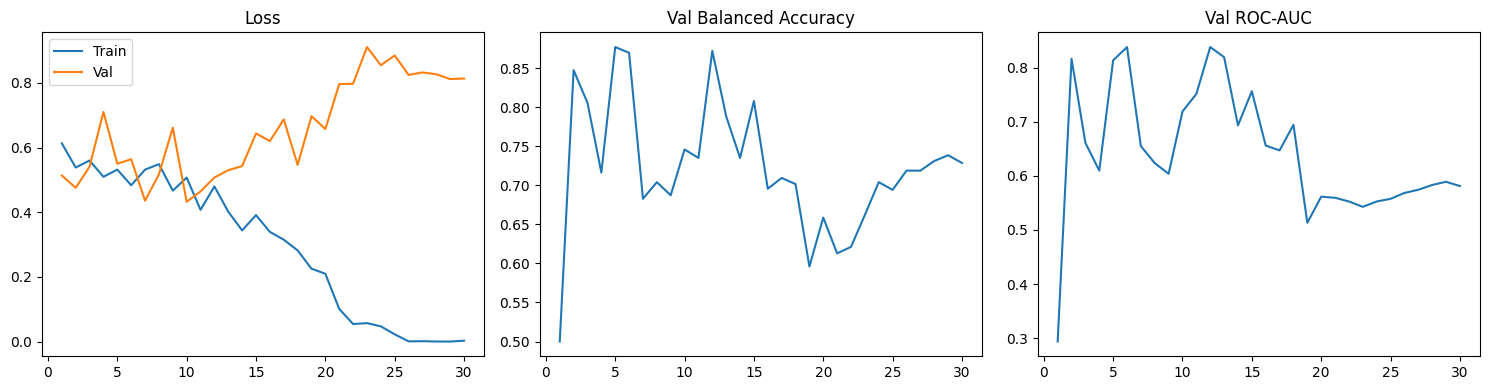

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(epochs, history['val_bacc'])
axes[1].set_title('Val Balanced Accuracy')

axes[2].plot(epochs, history['val_auc'])
axes[2].set_title('Val ROC-AUC')

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120)
plt.show()

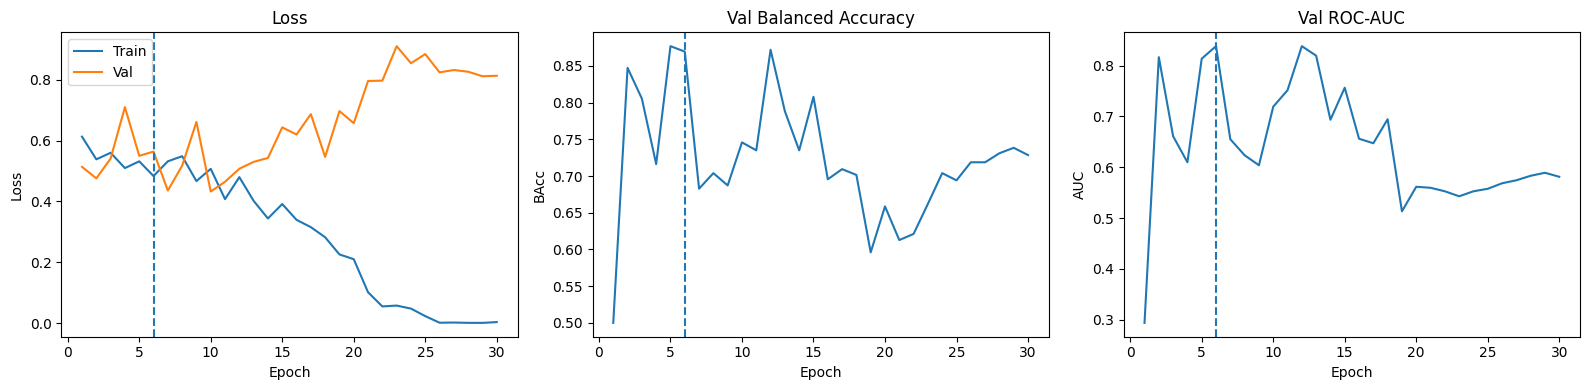

Best epoch: 6
Best Val AUC: 0.8384


In [19]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs = range(1, len(history['train_loss']) + 1)

# --------------------------------------------------
# Loss
# --------------------------------------------------
axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'], label='Val')

# Mark best epoch (based on AUC)
best_epoch = np.argmax(history['val_auc']) + 1
axes[0].axvline(best_epoch, linestyle='--')

axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# --------------------------------------------------
# Balanced Accuracy
# --------------------------------------------------
axes[1].plot(epochs, history['val_bacc'])
axes[1].axvline(best_epoch, linestyle='--')

axes[1].set_title('Val Balanced Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('BAcc')

# --------------------------------------------------
# ROC-AUC
# --------------------------------------------------
axes[2].plot(epochs, history['val_auc'])
axes[2].axvline(best_epoch, linestyle='--')

axes[2].set_title('Val ROC-AUC')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

print(f"Best epoch: {best_epoch}")
print(f"Best Val AUC: {max(history['val_auc']):.4f}")

## 11. Evaluate on hold-out test set

=== Test Set Results ===
              precision    recall  f1-score   support

      normal       0.99      0.77      0.87       203
     delayed       0.10      0.83      0.17         6

    accuracy                           0.77       209
   macro avg       0.54      0.80      0.52       209
weighted avg       0.97      0.77      0.85       209

ROC-AUC: 0.7537


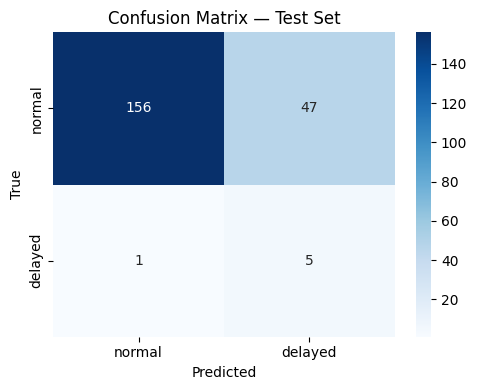

In [24]:
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --------------------------------------------------
# IMPORTANT: DO NOT RECREATE MODEL IF ALREADY TRAINED
# --------------------------------------------------
model.to(device)
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()


all_labels, all_probs = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        logits = model(images)
        probs = F.softmax(logits, dim=1)[:, 1]

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# --------------------------------------------------
# Dynamic threshold (BETTER than 0.5)
# --------------------------------------------------
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
best_threshold = thresholds[np.argmax(tpr - fpr)]

all_preds = (all_probs >= best_threshold).astype(int)

# --------------------------------------------------
# RESULTS
# --------------------------------------------------
print("=== Test Set Results ===")
print(classification_report(
    all_labels,
    all_preds,
    target_names=['normal', 'delayed']
))

if len(np.unique(all_labels)) > 1:
    print(f"ROC-AUC: {roc_auc_score(all_labels, all_probs):.4f}")
else:
    print("ROC-AUC: Not defined (single class present)")


# --------------------------------------------------
# CONFUSION MATRIX
# --------------------------------------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['age', 'delayed'],
    yticklabels=['normal', 'delayed']
)

plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix — Test Set')

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

## 12. ROC curve

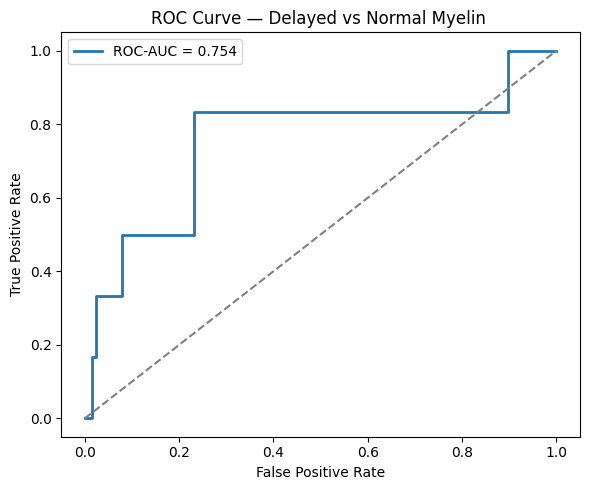

In [18]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_score   = roc_auc_score(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'ROC-AUC = {auc_score:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Delayed vs Normal Myelin ')
plt.legend()
plt.tight_layout()
plt.savefig('/content/roc_curve_new_pred.png', dpi=120)
plt.show()

## 13. (Optional) GradCAM saliency on one test volume

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 79.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


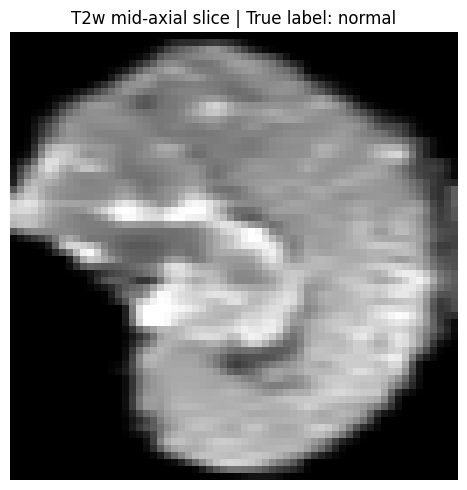

In [21]:
# Install grad-cam for 3D support
!pip install -q grad-cam

# Visualise a single mid-axial slice from the first test subject
sample_image, sample_label = test_ds[0]
sample_image = sample_image.unsqueeze(0).to(device)   # (1, 2, D, H, W)

# Show T2w mid-slice
t2_vol = sample_image[0, 1].cpu().numpy()             # (D, H, W)
mid    = t2_vol.shape[0] // 2

plt.figure(figsize=(5, 5))
plt.imshow(t2_vol[mid], cmap='gray')
plt.title(f"T2w mid-axial slice | True label: {'delayed' if sample_label==1 else 'normal'}")
plt.axis('off')
plt.tight_layout()
plt.savefig('/content/sample_t2w_slice.png', dpi=120)
plt.show()

---
## Notes
- **Dataset download** takes ~10–20 min; the ~833 NIfTI pairs are several GB total.
- **`TARGET_SHAPE`** is set to `(64,64,64)` to fit in GPU RAM. Raise to `(96,96,96)` for better accuracy at the cost of memory.
- **Class imbalance**: weighted cross-entropy is applied automatically based on label counts.
- **Accelerated class** is excluded by the binary filter in cell 4 — remove the filter and change `num_classes=3` to include it.
- **Cite the dataset**: Akinci D'Antonoli et al., Radiology: AI, https://pubs.rsna.org/doi/10.1148/ryai.220292